# Modeling Template

This is a template made for loading data from thousands of random Pokemon generation 9 battles from https://pokemonshowdown.com/ and using features from a csv to create models which predict the winner. 

# Outline
## Section 1: Modeling
### 1.1 Logistic Regression
    1.1.1 Baseline model
    1.1.2 Improvements
### 1.2 Decision Tree
### 1.3 Random Forest
### 1.4 Histogram-based Gradient Boosting Classification Tree
### 1.5 XGBoost
## Section 2: Model Comparisons
### 2.1 AUC score
### 2.2 Cross Validation Score
## Section 3: Best Model Analysis
### 3.1 ROC Curve
### 3.2 Confusion Matrix

In [1]:
# Import statements
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [2]:
from sklearn.model_selection import train_test_split
# Load in training dataframe
path_to_train = "../data/data_cleaned.csv.zip"
full_df = pd.read_csv(path_to_train)
df = full_df[full_df["p1elo0"] > 0]
df['elo_diff'] = df['p1elo0'] - df['p2elo0']
train_df,test_df = train_test_split(df,test_size=0.2,shuffle=True,random_state=207)


/var/folders/sf/b89tnv8s1q36k0tyzfh47bb80000gn/T/ipykernel_86394/520244123.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['elo_diff'] = df['p1elo0'] - df['p2elo0']


# Section 1: Modeling
## 1.1 Logistic Regression
### 1.1.1 Baseline Model

We begin with a simple model using only one feature to predict battle outcome. Following models will add features to see if this baseline model can be improved.

In [ ]:
# my model is already pretty simple so we should skip this part


### 1.1.2 Improvements

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

features = ['M11_type1', 'M11_type2', 'M21_type1', 'M21_type2', 'elo_diff']
categorical_features = ['M11_type1', 'M11_type2', 'M21_type1', 'M21_type2']

X_train = train_df[features]
X_test = test_df[features]
y_train = train_df["p1_win"]
y_test = test_df["p1_win"]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], 
    remainder='passthrough'
)

lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)

lr_pred = lr.predict_proba(X_test)[:,1]

## 1.2 Decision Tree

In [4]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=0))
])

dt_param_grid = {
    "classifier__max_depth": [3, 5, 8, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid=dt_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:")
print(dt_grid.best_params_)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}


In [5]:
dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=0,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=20
    ))
])

dt.fit(X_train, y_train)
dt_pred = dt.predict_proba(X_test)[:,1]

## 1.3 Random Forest

In [6]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=0))
])

rf_param_grid = {
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__min_samples_leaf": [5, 10, 20],
    "classifier__n_estimators": [200, 500, 800]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'classifier__max_depth': 6, 'classifier__min_samples_leaf': 20, 'classifier__n_estimators': 800}


In [7]:
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=800,
        max_depth=6,
        min_samples_leaf=20,
        random_state=0
    ))
])

rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:,1]

## 1.4 Histogram-based Gradient Boosting Classification Tree

In [8]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ], 
    remainder='passthrough'
)

# note HGBClassifier requires dense input, so we set sparse_output=False in the OneHotEncoder 

hgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', HistGradientBoostingClassifier(random_state=0))
])

hgb_param_grid = {
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__min_samples_leaf": [5, 10, 20],
    "classifier__max_iter": [100, 200, 500] 
}

grid = GridSearchCV(
    hgb_pipeline,
    param_grid=hgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'classifier__max_depth': 4, 'classifier__max_iter': 100, 'classifier__min_samples_leaf': 20}


In [9]:
hgb = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=100,
        max_depth=4,
        min_samples_leaf=20,
        random_state=0
    ))
])

hgb.fit(X_train, y_train)
hgb_pred = hgb.predict_proba(X_test)[:, 1]

## 1.5 XGBoost

In [10]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=0))
])

xgb_param_grid = {
    "classifier__max_depth": [4, 6, 8, 10],
    "classifier__min_child_weight": [5, 10, 20], 
    "classifier__n_estimators": [200, 500, 800] 
}

grid = GridSearchCV(
    xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'classifier__max_depth': 4, 'classifier__min_child_weight': 20, 'classifier__n_estimators': 200}


In [11]:
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        min_child_weight=20,
        random_state=0
    ))
])

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict_proba(X_test)[:, 1]

# Section 2: Model Comparisons
## 2.1 AUC score

In [12]:
print(f"AUC Scores")
#print(f"Baseline Model: {roc_auc_score(y_test, base_pred)}")
print(f"Logistic Regression: {roc_auc_score(y_test, lr_pred)}")
print(f"Decision Tree: {roc_auc_score(y_test, dt_pred)}")
print(f"Random Forest: {roc_auc_score(y_test, rf_pred)}")
print(f"HistGradientBoosting: {roc_auc_score(y_test, hgb_pred)}")
print(f"XGBoost: {roc_auc_score(y_test, xgb_pred)}")

AUC Scores
Logistic Regression: 0.5075720637117662
Decision Tree: 0.511101520966372
Random Forest: 0.5174408469386685
HistGradientBoosting: 0.5154701704992293
XGBoost: 0.5126658723667515


## 2.2 Cross Validation Score

In [13]:
lr_cvscore = cross_val_score(lr, X_train, y_train, cv=5, scoring="roc_auc")
dt_cvscore = cross_val_score(dt, X_train, y_train, cv=5, scoring="roc_auc")
rf_cvscore = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")
hgb_cvscore = cross_val_score(hgb, X_train, y_train, cv=5, scoring="roc_auc")
xgb_cvscore = cross_val_score(xgb, X_train, y_train, cv=5, scoring="roc_auc")

print("Cross-Validation Scores") 
print(f"Linear Regression: {lr_cvscore.mean():.3f} +/- {lr_cvscore.std():.3f}")
print(f"Decision Tree: {dt_cvscore.mean():.3f} +/- {dt_cvscore.std():.3f}")
print(f"Random Forest: {rf_cvscore.mean():.3f} +/- {rf_cvscore.std():.3f}")
print(f"HistGradientBoosting: {hgb_cvscore.mean():.3f} +/- {hgb_cvscore.std():.3f}")
print(f"XGBoost: {xgb_cvscore.mean():.3f} +/- {xgb_cvscore.std():.3f}")

Cross-Validation Scores
Linear Regression: 0.518 +/- 0.013
Decision Tree: 0.515 +/- 0.011
Random Forest: 0.522 +/- 0.013
HistGradientBoosting: 0.517 +/- 0.013
XGBoost: 0.511 +/- 0.011


# Section 3: Best Model Analysis
## 3.1 ROC Curve

#### Choose best model and uncomment it below
 - Linear regression model = lr
 - Decision tree model = dt
 - Random forest model = rf

In [14]:
# Choose best model
#best_model = lr
#best_model = dt
best_model = rf
#best_model = hgb
#best_model = xgb

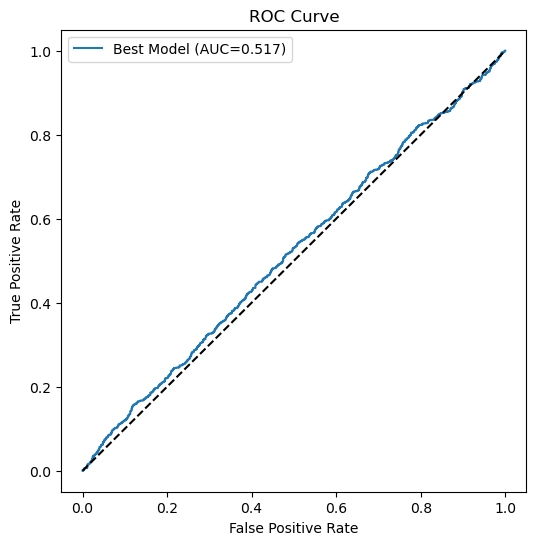

In [15]:
prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"Best Model (AUC={roc_auc_score(y_test, prob):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## 3.2 Confusion Matrix

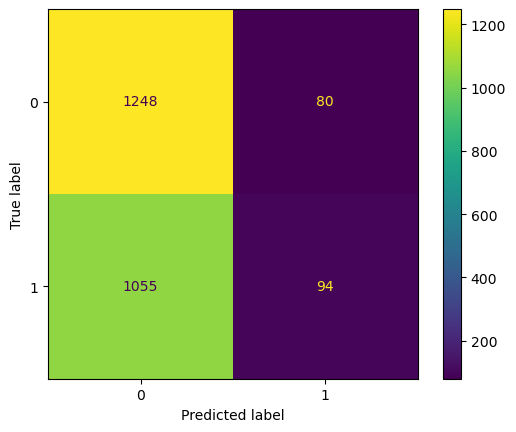

In [16]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)